In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def annotate_bar_values(ax, fmt='{:.0f}', padding=4, fontsize=9):
    """Add readable labels to every bar in the axis."""
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            if pd.isna(value):
                labels.append('')
            else:
                labels.append(fmt.format(value))
        ax.bar_label(container, labels=labels, padding=padding, fontsize=fontsize)


def annotate_line_points(ax, fmt='${:,.0f}', fontsize=8, y_offset=8):
    """Label each point for single-series line charts."""
    for line in ax.get_lines():
        x_data = line.get_xdata()
        y_data = line.get_ydata()
        for x, y in zip(x_data, y_data):
            if pd.isna(y):
                continue
            ax.annotate(
                fmt.format(y),
                (x, y),
                textcoords='offset points',
                xytext=(0, y_offset),
                ha='center',
                fontsize=fontsize,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none')
            )


def annotate_line_endpoints(ax, fmt='{:.0f}', fontsize=8):
    """Label only the end-point of each line to keep multi-series charts readable."""
    for line in ax.get_lines():
        x_data = line.get_xdata()
        y_data = line.get_ydata()
        if len(x_data) == 0:
            continue
        x_last = x_data[-1]
        y_last = y_data[-1]
        if pd.isna(y_last):
            continue
        ax.annotate(
            fmt.format(y_last),
            (x_last, y_last),
            textcoords='offset points',
            xytext=(6, 0),
            ha='left',
            va='center',
            fontsize=fontsize,
            color=line.get_color(),
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none')
        )

In [43]:
# 1. Load Data
df = pd.read_csv('goodstack.csv')

In [44]:
# 2. Data Cleaning
# Convert date columns to datetime
df['CREATED_AT'] = pd.to_datetime(df['CREATED_AT'], errors='coerce')
df['MONTH_YEAR'] = df['CREATED_AT'].dt.to_period('M')
# Removing the one low value donation from 2021 to prevent long tail in time series
df = df[df['CREATED_AT'] >= '2022-01-01']
df.head()

/var/folders/pc/w4rfj05x6vj099qm1158dcyw0000gn/T/ipykernel_97212/1374053320.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['MONTH_YEAR'] = df['CREATED_AT'].dt.to_period('M')


,DONATION_ID,DISBURSEMENT_ID,DISBURSEMENT_BATCH_ID,FOUNDATION_ID,FOUNDATION_NAME,PARTNER_ID,PARTNER_NAME,SUBSIDIARY_ID,SUBSIDIARY_NAME,ORGANISATION_ID,...,DONATION_REQUEST_AMOUNT,DONATION_FEE_CURRENCY,DONATION_FEE_AMOUNT,DONATION_FEE_AMOUNT_USD,ACTUAL_ORGANISATION_CURRENCY,ATTRIBUTED_ORGANISATION_AMOUNT,ATTRIBUTED_ORGANISATION_AMOUNT_USD,SUBSIDIARY_FEE_CURRENCY,SUBSIDIARY_FEE_AMOUNT,MONTH_YEAR
0,donation_000000D8LWuynwldBDEQkUd3YPcZx,NaN,NaN,foundation_000000CS58uchzd01CInAFMQI8WG0,Foundation_Name_2,partner_000000CBRzAHRM9WxOQCLvDOxYEIC,Partner_Name_1,subsidiary_000000CwBmCJsFXyzCjKluHzd2I76,Subsidiary_Name_2,organisation_000000D6DKVVvbgxjvb3bDeRgkibD,...,NaN,EUR,2.75,3.170723,NaN,NaN,NaN,EUR,2.750000,2025-07
1,donation_000000D8b6HOxccpdlyk1b0RjzjcL,NaN,NaN,foundation_000000CS58uchzd01CInAFMQI8WG0,Foundation_Name_2,partner_000000CBRzAHRM9WxOQCLvDOxYEIC,Partner_Name_1,subsidiary_000000CwBmCQjhgnwNtUG07IN0ahM,Subsidiary_Name_5,organisation_000000CDyML85ueQGyKRCP3aHUYfR,...,NaN,EUR,2.75,3.174310,NaN,NaN,NaN,EUR,2.750000,2025-08
2,donation_000000D6rHdBHO1hFLRvUYIXLp2vY,NaN,NaN,foundation_000000CS58uchzd01CInAFMQI8WG0,Foundation_Name_2,partner_000000CBRzAHRM9WxOQCLvDOxYEIC,Partner_Name_1,subsidiary_000000CwBmCJsFXyzCjKluHzd2I76,Subsidiary_Name_2,organisation_000000CdYWIfEieniAukfiepfJ8wy,...,NaN,EUR,2.75,3.156420,NaN,NaN,NaN,EUR,2.750000,2025-06
3,donation_000000D8cKM8lPkyeajyE5Jw3l6LU,NaN,NaN,foundation_000000CS58uchzd01CInAFMQI8WG0,Foundation_Name_2,partner_000000CBRzAHRM9WxOQCLvDOxYEIC,Partner_Name_1,subsidiary_000000CwBmCJsFXyzCjKluHzd2I76,Subsidiary_Name_2,organisation_000000C6zmp0iNF3IQqmzNhBvpZav,...,NaN,EUR,2.75,3.203559,NaN,NaN,NaN,EUR,2.750000,2025-08
4,donation_000000D8fZB5QiHObIQQXyD85WaBw,NaN,NaN,foundation_000000CS58uchzd01CInAFMQI8WG1,Foundation_Name_1,partner_000000CBRzAHRM9WxOQCLvDOxYEIC,Partner_Name_1,subsidiary_000000CwBmCQj551MGyv5JB5b2Pa4,Subsidiary_Name_1,organisation_000000C704H83EOFbsuZcKjbViHFy,...,NaN,AUD,2.27,1.466114,NaN,NaN,NaN,GBP,1.104072,2025-08


In [ ]:
# 3. KPI Calculations for Report
total_donations = len(df)
total_usd = df['DONATION_AMOUNT_USD'].sum()

# Status breakdown
status_counts = df['DONATION_STATUS'].value_counts(normalize=True) * 100
unable_to_pay_rate = status_counts.get('unable_to_pay', 0)

# Top Geographies

# country + status breakdown
top_countries = (
df.groupby(['ORGANISATION_COUNTRY', 'DONATION_STATUS'], as_index=False)['DONATION_AMOUNT_USD'].sum().sort_values('DONATION_AMOUNT_USD', ascending=False)
)

top_countries_total = (
    top_countries
    .drop(columns='DONATION_STATUS', errors='ignore')
    .groupby('ORGANISATION_COUNTRY', as_index=False)['DONATION_AMOUNT_USD']
    .sum()
    .sort_values('DONATION_AMOUNT_USD', ascending=False)
)

top_country_1 = top_countries_total.iloc[0]['ORGANISATION_COUNTRY'] 
top_country_1_pct = (top_countries_total.iloc[0]['DONATION_AMOUNT_USD'] / total_usd * 100) if len(top_countries_total) > 0 else 0

# Top Partners
top_partners = df.groupby('PARTNER_NAME')['DONATION_AMOUNT_USD'].sum().sort_values(ascending=False)


# Print Metrics for the Report
print("--- METRICS FOR LEADERSHIP REPORT ---")
print(f"Total Donation Volume: {total_donations:,.0f}")
print(f"Total Donation Value (USD): ${total_usd:,.2f}")
print(f"Unable to Pay Rate: {unable_to_pay_rate:.1f}%")
print(f"Top Country: {top_country_1} ({top_country_1_pct:.1f}% of total USD)")
print("-------------------------------------\n")
print(f"Top 5 Countries by Donation Value:\n{top_countries_total.head()}\n")
print("-------------------------------------\n")
print(f"Top partners by donation value:\n{top_partners}\n")

--- METRICS FOR LEADERSHIP REPORT ---
Total Donation Volume: 499
Total Donation Value (USD): $35,133.77
Unable to Pay Rate: 51.9%
Top Country: United Kingdom (31.1% of total USD)
-------------------------------------

Top 5 Countries by Donation Value:
   ORGANISATION_COUNTRY  DONATION_AMOUNT_USD
16       United Kingdom         10918.213293
1             Australia          9849.514864
5               Germany          4785.978460
14              Romania          3046.421783
11          Netherlands          2155.668166

-------------------------------------

Top partners by donation value:
PARTNER_NAME
Partner_Name_1    34244.018628
Partner_Name_6      630.480000
Partner_Name_7      150.000000
Partner_Name_4       68.580990
Partner_Name_3       32.685581
Partner_Name_2        8.000000
Name: DONATION_AMOUNT_USD, dtype: float64



Saved: 1_donations_over_time.png


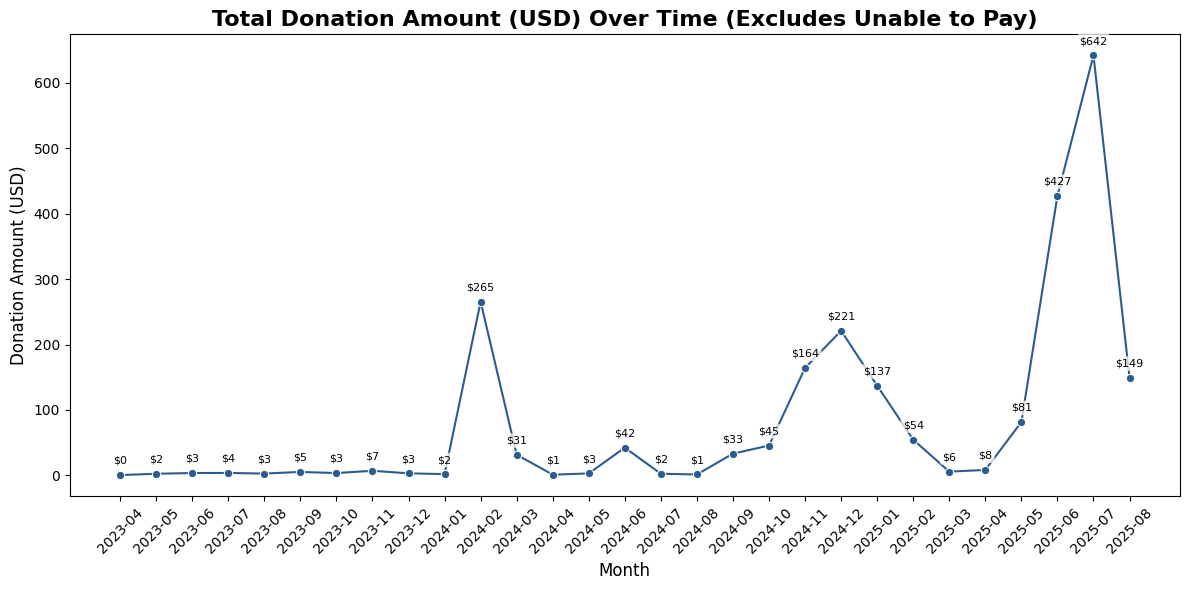

In [47]:
# Plot 1: Total Donations Over Time
monthly_trends = (
    df[df['DONATION_STATUS'] != 'unable_to_pay']
    .groupby('MONTH_YEAR')['DONATION_AMOUNT_USD']
    .sum()
    .reset_index()
)
monthly_trends['MONTH_YEAR'] = monthly_trends['MONTH_YEAR'].astype(str)

plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=monthly_trends,
    x='MONTH_YEAR',
    y='DONATION_AMOUNT_USD',
    marker='o',
    color='#2b5c8f'
)

# Add readable value labels above each point
for i, row in monthly_trends.reset_index(drop=True).iterrows():
    ax.annotate(
        f"${row['DONATION_AMOUNT_USD']:,.0f}",
        (i, row['DONATION_AMOUNT_USD']),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none')
    )

plt.title('Total Donation Amount (USD) Over Time (Excludes Unable to Pay)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Donation Amount (USD)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.tight_layout()
plt.savefig('1_donations_over_time.png', dpi=300)
print("Saved: 1_donations_over_time.png")

Saved: 2_top_countries.png


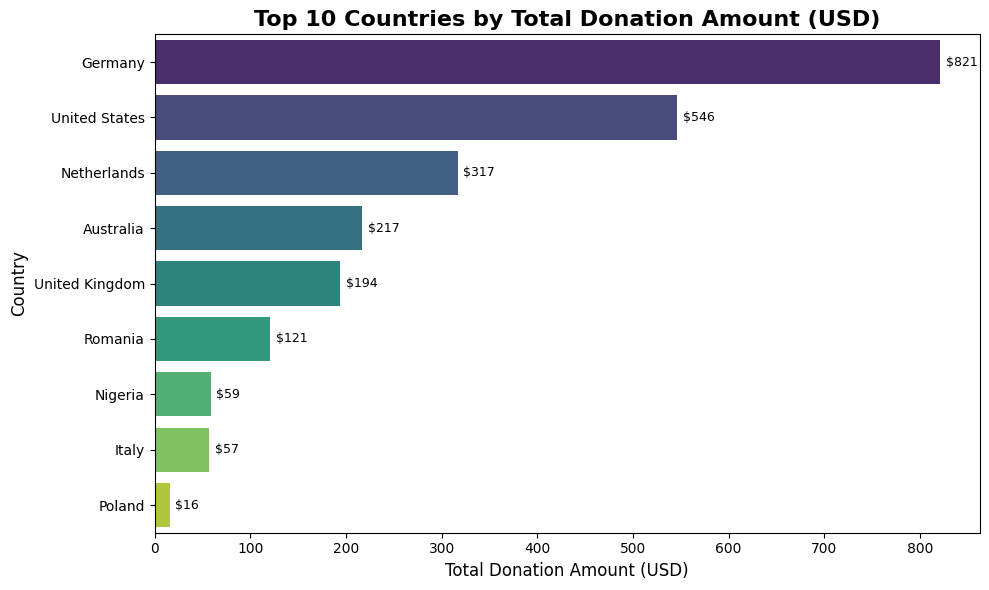

In [48]:
# Plot 2: Top 10 Countries by Donation USD (excluding unable_to_pay)
plt.figure(figsize=(10, 6))

top_countries_no_unable = top_countries[top_countries['DONATION_STATUS'] != 'unable_to_pay']

top_10_countries = (
    top_countries_no_unable
    .groupby('ORGANISATION_COUNTRY', as_index=False)['DONATION_AMOUNT_USD']
    .sum()
    .sort_values('DONATION_AMOUNT_USD', ascending=False)
    .head(10)
)

ax = sns.barplot(
    data=top_10_countries,
    x='DONATION_AMOUNT_USD',
    y='ORGANISATION_COUNTRY',
    hue='ORGANISATION_COUNTRY',
    palette='viridis',
    legend=False
)

annotate_bar_values(ax, fmt='${:,.0f}', padding=4, fontsize=9)

plt.title('Top 10 Countries by Total Donation Amount (USD)', fontsize=16, fontweight='bold')
plt.xlabel('Total Donation Amount (USD)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.savefig('2_top_countries.png', dpi=300)
print("Saved: 2_top_countries.png")

Saved: 3_status_breakdown.png


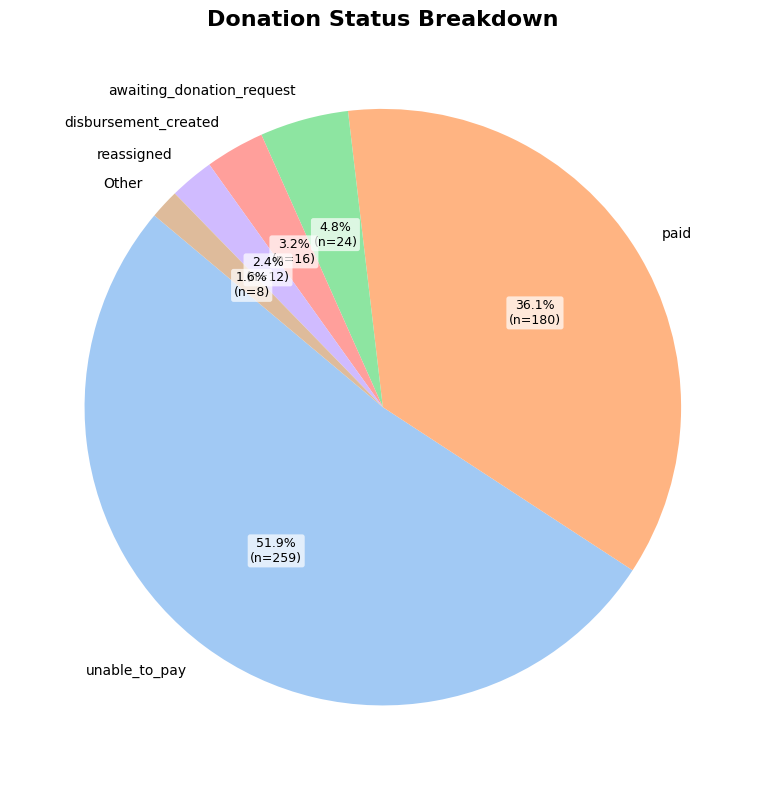

In [49]:
# Plot 3: Donation Status Breakdown
plt.figure(figsize=(8, 8))
# Filter to top 5 statuses to avoid clutter, group rest as 'Other'
top_statuses = df['DONATION_STATUS'].value_counts().nlargest(5)
other_statuses = pd.Series({'Other': df['DONATION_STATUS'].value_counts().iloc[5:].sum()})
plot_statuses = pd.concat([top_statuses, other_statuses])
plot_statuses = plot_statuses[plot_statuses > 0]

def pie_label(pct):
    total = plot_statuses.sum()
    count = int(round(pct * total / 100.0))
    return f"{pct:.1f}%\n(n={count})"

wedges, texts, autotexts = plt.pie(
    plot_statuses.values,
    labels=plot_statuses.index,
    autopct=pie_label,
    startangle=140,
    colors=sns.color_palette('pastel'),
    textprops={'fontsize': 10}
)

for text in autotexts:
    text.set_fontsize(9)
    text.set_bbox(dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

plt.title('Donation Status Breakdown', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('3_status_breakdown.png', dpi=300)
print("Saved: 3_status_breakdown.png")

Saved: 4_top_partners.png


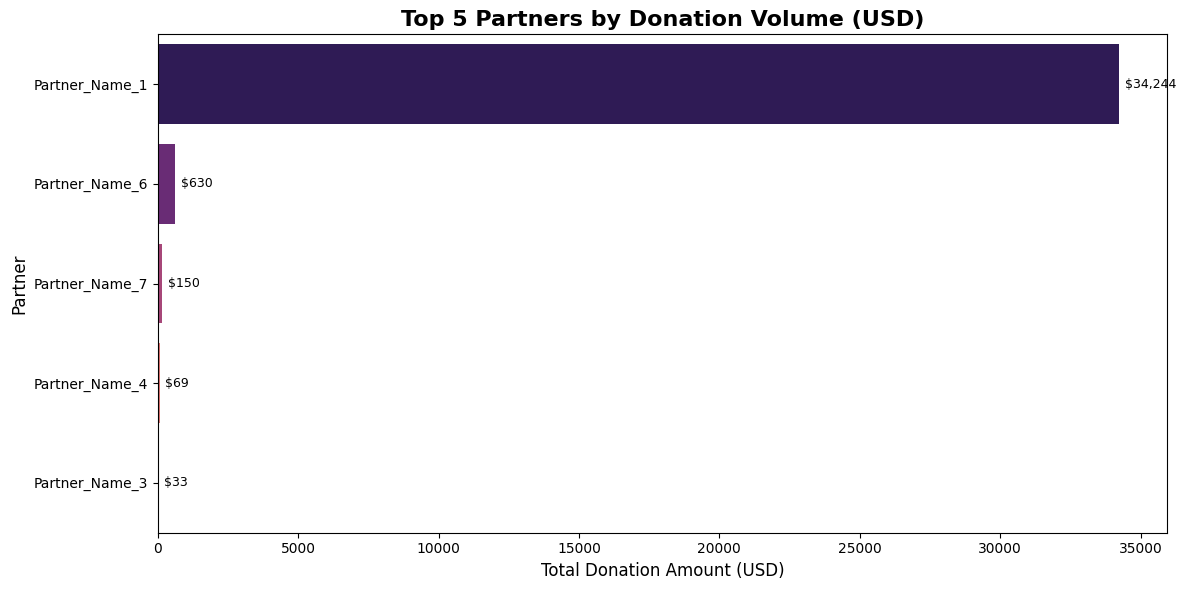

In [53]:
# Plot 4: Top 5 Partners
plt.figure(figsize=(12, 6))
top_5_partners = top_partners.head(5)

ax = sns.barplot(
    x=top_5_partners.values,
    y=top_5_partners.index,
    hue=top_5_partners.index,
    palette='magma',
    legend=False
)

annotate_bar_values(ax, fmt='${:,.0f}', padding=4, fontsize=9)

plt.title('Top 5 Partners by Donation Volume (USD)', fontsize=16, fontweight='bold')
plt.xlabel('Total Donation Amount (USD)', fontsize=12)
plt.ylabel('Partner', fontsize=12)
plt.tight_layout()
plt.savefig('4_top_partners.png', dpi=300)
print("Saved: 4_top_partners.png")

In [23]:

# TABLE: Status Breakdown Detailed
print("\n=== DONATION STATUS BREAKDOWN (DETAILED) ===")
status_breakdown = df['DONATION_STATUS'].value_counts().reset_index()
status_breakdown.columns = ['Status', 'Count']
status_breakdown['% of Total'] = (status_breakdown['Count'] / total_donations * 100).round(2)
status_breakdown = status_breakdown.sort_values('Count', ascending=False)
print(status_breakdown.to_string(index=False))
print(f"\nUnable to Pay Rate: {unable_to_pay_rate:.2f}%")



=== DONATION STATUS BREAKDOWN (DETAILED) ===
                     Status  Count  % of Total
              unable_to_pay    259       51.90
                       paid    180       36.07
  awaiting_donation_request     24        4.81
       disbursement_created     16        3.21
                 reassigned     12        2.40
awaiting_disbursement_batch      5        1.00
     below_payout_threshold      3        0.60

Unable to Pay Rate: 51.90%


In [54]:

# ANALYSIS: Volume, Total & Average Donations by Foundation/Organisation
print("\n" + "="*70)
print("INSIGHT #5: DONATIONS BY FOUNDATION/ORGANISATION")
print("="*70)

# By Foundation
print("\n--- TOP 10 FOUNDATIONS BY DONATION VALUE ---")
foundation_stats = df[df['FOUNDATION_NAME'].notna()].groupby('FOUNDATION_NAME').agg({
    'DONATION_AMOUNT_USD': ['count', 'sum', 'mean']
}).round(2)
foundation_stats.columns = ['Donation_Count', 'Total_USD', 'Avg_USD']
foundation_stats = foundation_stats.sort_values('Total_USD', ascending=False).reset_index()
foundation_stats.columns = ['Foundation Name', 'Donation Count', 'Total USD', 'Avg USD per Donation']
print(foundation_stats.head(10).to_string(index=False))

# By Organisation
print("\n--- TOP 15 ORGANISATIONS BY DONATION VALUE ---")
org_stats = df.groupby('ORGANISATION_NAME').agg({
    'DONATION_AMOUNT_USD': ['count', 'sum', 'mean']
}).round(2)
org_stats.columns = ['Donation_Count', 'Total_USD', 'Avg_USD']
org_stats = org_stats.sort_values('Total_USD', ascending=False).reset_index()
org_stats.columns = ['Organisation Name', 'Donation Count', 'Total USD', 'Avg USD per Donation']
print(org_stats.head(15).to_string(index=False))

# Summary statistics
print("\n--- ORGANISATION STATISTICS SUMMARY ---")
print(f"Total Unique Organisations: {df['ORGANISATION_NAME'].nunique():,.0f}")
print(f"Average Donations per Organisation: {df['ORGANISATION_NAME'].value_counts().mean():.2f}")
print(f"Median Donations per Organisation: {df['ORGANISATION_NAME'].value_counts().median():.0f}")
print(f"Organisation with Most Donations: {df['ORGANISATION_NAME'].value_counts().index[0]} ({df['ORGANISATION_NAME'].value_counts().iloc[0]} donations)")



INSIGHT #5: DONATIONS BY FOUNDATION/ORGANISATION

--- TOP 10 FOUNDATIONS BY DONATION VALUE ---
  Foundation Name  Donation Count  Total USD  Avg USD per Donation
Foundation_Name_2             225   23861.39                106.05
Foundation_Name_1             221    9839.95                 44.52
Foundation_Name_3              29    1413.56                 48.74

--- TOP 15 ORGANISATIONS BY DONATION VALUE ---
    Organisation Name  Donation Count  Total USD  Avg USD per Donation
Organisation_Name_130              33    7209.17                218.46
 Organisation_Name_67               3    4261.71               1420.57
 Organisation_Name_13              14    2575.73                183.98
Organisation_Name_107               7    1287.61                183.94
 Organisation_Name_74               1    1239.80               1239.80
  Organisation_Name_2              19    1221.89                 64.31
Organisation_Name_104              19    1038.93                 54.68
 Organisation_Name_3

Saved: 10_payment_method_vs_status.png


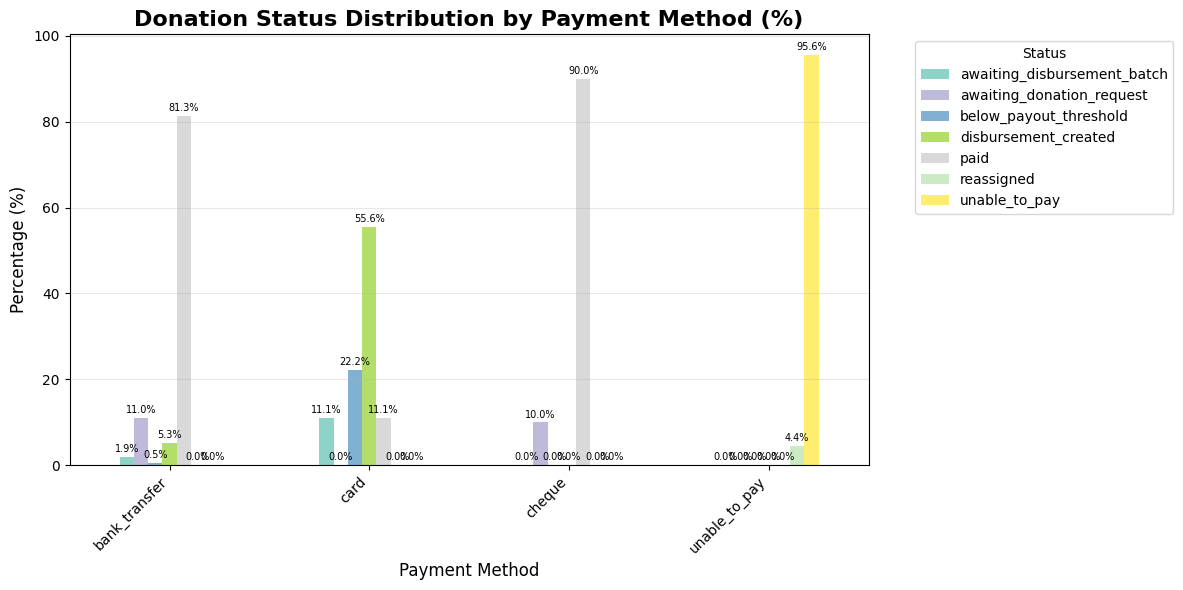

In [55]:
# VISUALIZATION: Payment Method by Status
payment_status = pd.crosstab(df['PAYMENT_METHOD'], df['DONATION_STATUS'], normalize='index') * 100
ax = payment_status.plot(kind='bar', stacked=False, figsize=(12, 6), colormap='Set3')

annotate_bar_values(ax, fmt='{:.1f}%', padding=2, fontsize=7)

plt.title('Donation Status Distribution by Payment Method (%)', fontsize=16, fontweight='bold')
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('10_payment_method_vs_status.png', dpi=300)
print("Saved: 10_payment_method_vs_status.png")

Saved: 9_top_orgs_by_volume.png


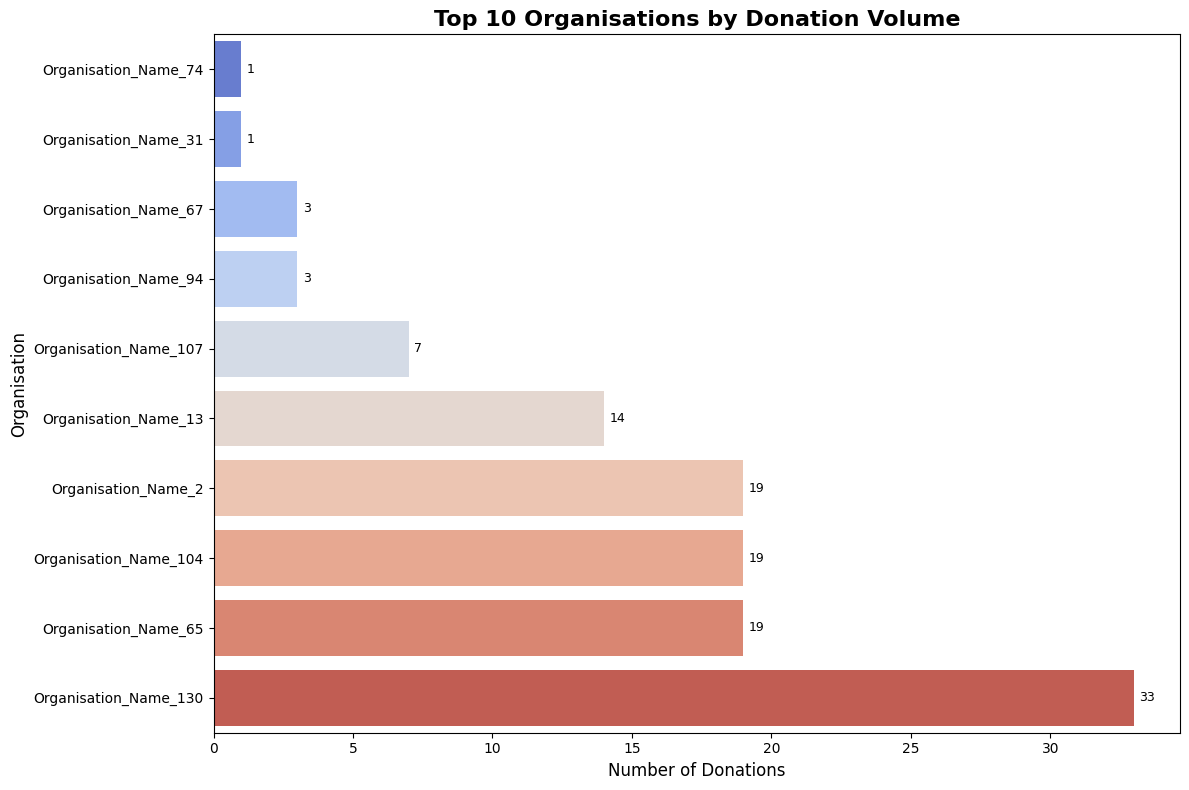

In [56]:
# VISUALIZATION: Top 10 Organizations by Donation Volume
plt.figure(figsize=(12, 8))
top_10_orgs = org_stats.head(10).sort_values('Donation Count')
ax = sns.barplot(
    data=top_10_orgs,
    y='Organisation Name',
    x='Donation Count',
    hue='Organisation Name',
    palette='coolwarm',
    legend=False
)
annotate_bar_values(ax, fmt='{:.0f}', padding=4, fontsize=9)

plt.title('Top 10 Organisations by Donation Volume', fontsize=16, fontweight='bold')
plt.xlabel('Number of Donations', fontsize=12)
plt.ylabel('Organisation', fontsize=12)
plt.tight_layout()
plt.savefig('9_top_orgs_by_volume.png', dpi=300)
print("Saved: 9_top_orgs_by_volume.png")

Saved: 6_avg_donation_over_time.png


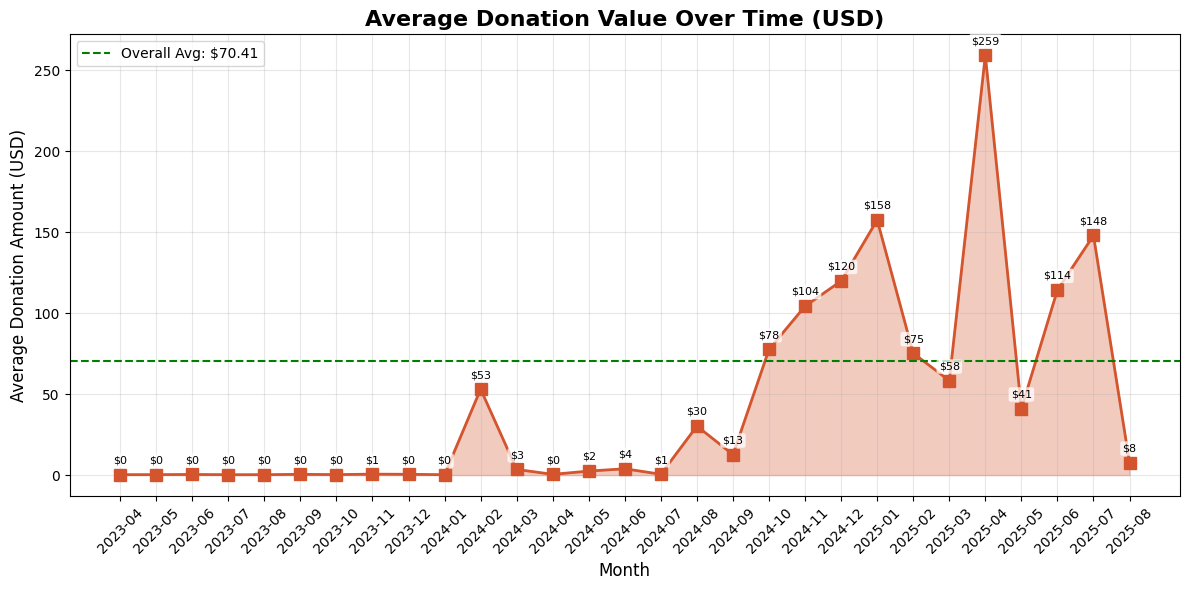

In [57]:
# VISUALIZATION: Average Donation Value Over Time
plt.figure(figsize=(12, 6))

monthly_avg_plot = (
    df.groupby('MONTH_YEAR', as_index=False)['DONATION_AMOUNT_USD']
    .mean()
    .rename(columns={'DONATION_AMOUNT_USD': 'Avg_USD'})
    .sort_values('MONTH_YEAR')
)
monthly_avg_plot['MONTH_YEAR'] = monthly_avg_plot['MONTH_YEAR'].astype(str)

ax = plt.gca()
ax.plot(range(len(monthly_avg_plot)), monthly_avg_plot['Avg_USD'], marker='s', linewidth=2, markersize=8, color='#d4542d')
ax.fill_between(range(len(monthly_avg_plot)), monthly_avg_plot['Avg_USD'], alpha=0.3, color='#d4542d')
annotate_line_points(ax, fmt='${:,.0f}', fontsize=8, y_offset=8)

plt.title('Average Donation Value Over Time (USD)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Donation Amount (USD)', fontsize=12)
plt.xticks(range(len(monthly_avg_plot)), monthly_avg_plot['MONTH_YEAR'], rotation=45)
plt.axhline(y=df['DONATION_AMOUNT_USD'].mean(), color='green', linestyle='--', label=f"Overall Avg: ${df['DONATION_AMOUNT_USD'].mean():.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('6_avg_donation_over_time.png', dpi=300)
print("Saved: 6_avg_donation_over_time.png")

Saved: 5_cumulative_donations.png


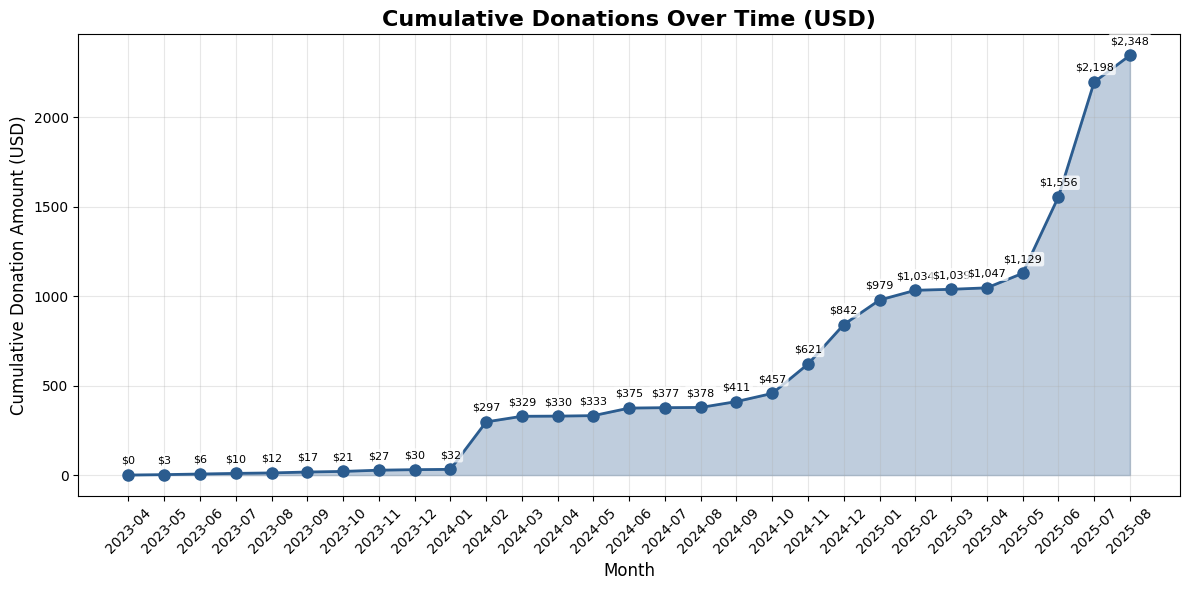

In [58]:
# VISUALIZATION: Cumulative Donations Over Time
plt.figure(figsize=(12, 6))
cumulative = monthly_trends.copy()
cumulative['MONTH_YEAR_STR'] = cumulative['MONTH_YEAR'].astype(str)
cumulative['Cumulative_USD'] = cumulative['DONATION_AMOUNT_USD'].cumsum()

ax = plt.gca()
ax.plot(range(len(cumulative)), cumulative['Cumulative_USD'], marker='o', linewidth=2, markersize=8, color='#2b5c8f')
ax.fill_between(range(len(cumulative)), cumulative['Cumulative_USD'], alpha=0.3, color='#2b5c8f')
annotate_line_points(ax, fmt='${:,.0f}', fontsize=8, y_offset=8)

plt.title('Cumulative Donations Over Time (USD)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Cumulative Donation Amount (USD)', fontsize=12)
plt.xticks(range(len(cumulative)), cumulative['MONTH_YEAR_STR'], rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('5_cumulative_donations.png', dpi=300)
print("Saved: 5_cumulative_donations.png")

In [29]:

# ANALYSIS: Average Donation Value Over Time
print("\n" + "="*70)
print("INSIGHT #6: AVERAGE DONATION VALUE TRENDS OVER TIME")
print("="*70)

monthly_avg = df.groupby('MONTH_YEAR').agg({
    'DONATION_AMOUNT_USD': ['count', 'sum', 'mean']
}).round(2)
monthly_avg.columns = ['Count', 'Total_USD', 'Avg_USD']
monthly_avg = monthly_avg.reset_index()
monthly_avg['MONTH_YEAR'] = monthly_avg['MONTH_YEAR'].astype(str)

print("\n--- Monthly Donation Metrics ---")
print(monthly_avg.to_string(index=False))

print(f"\nOverall Average Donation: ${df['DONATION_AMOUNT_USD'].mean():,.2f}")
print(f"Median Donation: ${df['DONATION_AMOUNT_USD'].median():,.2f}")
print(f"Min Donation: ${df['DONATION_AMOUNT_USD'].min():,.2f}")
print(f"Max Donation: ${df['DONATION_AMOUNT_USD'].max():,.2f}")



INSIGHT #6: AVERAGE DONATION VALUE TRENDS OVER TIME

--- Monthly Donation Metrics ---
MONTH_YEAR  Count  Total_USD  Avg_USD
   2023-04      1       0.26     0.26
   2023-05      8       2.31     0.29
   2023-06      9       3.41     0.38
   2023-07     14       3.53     0.25
   2023-08     13       3.40     0.26
   2023-09     11       5.10     0.46
   2023-10     11       3.35     0.30
   2023-11     12       6.88     0.57
   2023-12      6       2.92     0.49
   2024-01      7       1.72     0.25
   2024-02      5     265.42    53.08
   2024-03      9      31.39     3.49
   2024-04      2       0.92     0.46
   2024-05      5      12.37     2.47
   2024-06     12      46.77     3.90
   2024-07      5       2.59     0.52
   2024-08      5     151.37    30.27
   2024-09      3      37.95    12.65
   2024-10     24    1863.07    77.63
   2024-11     16    1669.82   104.36
   2024-12     52    6231.85   119.84
   2025-01     17    2678.83   157.58
   2025-02     25    1881.74    75.27
 

In [30]:

# ANALYSIS: Organisations Across Multiple Countries
print("\n" + "="*70)
print("INSIGHT #4: ORGANISATIONS OPERATING ACROSS MULTIPLE COUNTRIES")
print("="*70)

# Get all unique countries per organisation
org_countries = df.groupby('ORGANISATION_NAME')['ORGANISATION_COUNTRY'].nunique().reset_index()
org_countries.columns = ['ORGANISATION_NAME', 'Country_Count']
org_countries = org_countries.sort_values('Country_Count', ascending=False)

multi_country_orgs = org_countries[org_countries['Country_Count'] > 1]
print(f"\nTotal Organisations: {len(org_countries)}")
print(f"Organisations in Multiple Countries: {len(multi_country_orgs)}")
print(f"% of Organisations Multi-Country: {len(multi_country_orgs)/len(org_countries)*100:.2f}%")

print("\n--- Top 15 Organisations Operating in Multiple Countries ---")
print(multi_country_orgs.head(15).to_string(index=False))

# Show which countries they operate in
if len(multi_country_orgs) > 0:
    print("\n--- Multi-Country Organisations Details (Top 5) ---")
    for org in multi_country_orgs.head(5)['ORGANISATION_NAME']:
        countries = df[df['ORGANISATION_NAME'] == org]['ORGANISATION_COUNTRY'].unique()
        print(f"\n{org}: {', '.join(countries)}")



INSIGHT #4: ORGANISATIONS OPERATING ACROSS MULTIPLE COUNTRIES

Total Organisations: 142
Organisations in Multiple Countries: 0
% of Organisations Multi-Country: 0.00%

--- Top 15 Organisations Operating in Multiple Countries ---
Empty DataFrame
Columns: [ORGANISATION_NAME, Country_Count]
Index: []


In [31]:

# ANALYSIS: Organisations per Region Over Time (Using first donation received date)
print("\n" + "="*70)
print("INSIGHT #3: ORGANISATIONS PER REGION OVER TIME (ONBOARDING TREND)")
print("="*70)

# Get first donation date per organisation
org_first_donation = df.groupby('ORGANISATION_NAME')['CREATED_AT'].min().reset_index()
org_first_donation.columns = ['ORGANISATION_NAME', 'First_Donation_Date']

# Merge with country info
org_country_map = df[['ORGANISATION_NAME', 'ORGANISATION_COUNTRY']].drop_duplicates()
org_first_donation = org_first_donation.merge(org_country_map, on='ORGANISATION_NAME')

# Create month-year column
org_first_donation['Month_Year'] = org_first_donation['First_Donation_Date'].dt.to_period('M')

# Count organisations onboarded per month per country
org_onboarding = org_first_donation.groupby(['Month_Year', 'ORGANISATION_COUNTRY']).size().reset_index(name='New_Orgs')
org_onboarding['Month_Year'] = org_onboarding['Month_Year'].astype(str)

print("\n--- Top 5 Countries by Organisations Onboarded ---")
top_countries_by_org_count = org_first_donation['ORGANISATION_COUNTRY'].value_counts().head(10)
print(top_countries_by_org_count)

print("\n--- Organisations Onboarded Over Time (Sample) ---")
print(org_onboarding.sort_values('Month_Year', ascending=False).head(15).to_string(index=False))



INSIGHT #3: ORGANISATIONS PER REGION OVER TIME (ONBOARDING TREND)

--- Top 5 Countries by Organisations Onboarded ---
ORGANISATION_COUNTRY
Australia         41
United States     27
Germany           22
United Kingdom    18
Netherlands        9
Romania            6
Canada             3
Poland             3
France             2
Ukraine            2
Name: count, dtype: int64

--- Organisations Onboarded Over Time (Sample) ---
Month_Year ORGANISATION_COUNTRY  New_Orgs
   2025-07        United States         1
   2025-07              Romania         1
   2025-07          Netherlands         1
   2025-07              Germany         1
   2025-06        United States         3
   2025-06       United Kingdom         3
   2025-06              Romania         5
   2025-06               Poland         1
   2025-06              Nigeria         1
   2025-06          Netherlands         1
   2025-06                India         1
   2025-06               Brazil         1
   2025-06            Aust

/var/folders/pc/w4rfj05x6vj099qm1158dcyw0000gn/T/ipykernel_97212/760492135.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  org_first_donation['Month_Year'] = org_first_donation['First_Donation_Date'].dt.to_period('M')


In [32]:

# DEEP DIVE: Partner_Name_1 Analysis
print("\n" + "="*70)
print("INSIGHT #2: PARTNER_NAME_1 DEEP DIVE - PROCESSED MORE DONATIONS")
print("="*70)

partner1_df = df[df['PARTNER_NAME'] == 'Partner_Name_1'].copy()
print(f"\nTotal Donations: {len(partner1_df):,.0f}")
print(f"Total Value (USD): ${partner1_df['DONATION_AMOUNT_USD'].sum():,.2f}")
print(f"% of All Donations: {len(partner1_df)/total_donations*100:.2f}%")
print(f"% of Total Value: {partner1_df['DONATION_AMOUNT_USD'].sum()/total_usd*100:.2f}%")
print(f"Average Donation Value: ${partner1_df['DONATION_AMOUNT_USD'].mean():,.2f}")

print("\n--- Partner_Name_1 Status Breakdown ---")
p1_status = partner1_df['DONATION_STATUS'].value_counts().reset_index()
p1_status.columns = ['Status', 'Count']
p1_status['% of Partner'] = (p1_status['Count'] / len(partner1_df) * 100).round(2)
print(p1_status.to_string(index=False))

print("\n--- Partner_Name_1 Top 10 Countries ---")
p1_countries = partner1_df.groupby('ORGANISATION_COUNTRY')['DONATION_AMOUNT_USD'].sum().sort_values(ascending=False).head(10)
p1_countries_table = p1_countries.reset_index()
p1_countries_table.columns = ['Country', 'Total USD']
p1_countries_table['Count'] = [len(partner1_df[partner1_df['ORGANISATION_COUNTRY'] == c]) for c in p1_countries_table['Country']]
print(p1_countries_table.to_string(index=False))

print("\n--- Partner_Name_1 Top 10 Organisations ---")
p1_orgs = partner1_df.groupby('ORGANISATION_NAME').agg({'DONATION_AMOUNT_USD': ['sum', 'count']}).round(2)
p1_orgs.columns = ['Total USD', 'Donation Count']
p1_orgs = p1_orgs.sort_values('Total USD', ascending=False).head(10).reset_index()
print(p1_orgs.to_string(index=False))

# Compare with other partners
print("\n--- Partner_Name_1 vs Other Partners ---")
all_partners_stats = df.groupby('PARTNER_NAME').agg({
    'DONATION_AMOUNT_USD': ['count', 'sum', 'mean']
}).round(2)
all_partners_stats.columns = ['Donation Count', 'Total USD', 'Avg USD per Donation']
all_partners_stats = all_partners_stats.sort_values('Total USD', ascending=False).reset_index()
all_partners_stats.columns = ['Partner', 'Donation Count', 'Total USD', 'Avg USD per Donation']
print(all_partners_stats.head(5).to_string(index=False))



INSIGHT #2: PARTNER_NAME_1 DEEP DIVE - PROCESSED MORE DONATIONS

Total Donations: 290
Total Value (USD): $34,244.02
% of All Donations: 58.12%
% of Total Value: 97.47%
Average Donation Value: $118.08

--- Partner_Name_1 Status Breakdown ---
                     Status  Count  % of Partner
              unable_to_pay    245         84.48
       disbursement_created     16          5.52
                 reassigned     12          4.14
                       paid      7          2.41
awaiting_disbursement_batch      5          1.72
  awaiting_donation_request      3          1.03
     below_payout_threshold      2          0.69

--- Partner_Name_1 Top 10 Countries ---
       Country    Total USD  Count
United Kingdom 10918.213293     92
     Australia  9748.248293     53
       Germany  4785.978460     50
       Romania  3046.421783     19
   Netherlands  2155.668166     19
 United States   835.584225     17
         India   633.764601      1
         Italy   601.562620     11
       Ukr

In [33]:

# DEEP DIVE: Unable to Pay Status Analysis
print("\n" + "="*70)
print("INSIGHT #1: UNABLE TO PAY STATUS DEEP DIVE (51% of all donations)")
print("="*70)

unable_to_pay_df = df[df['DONATION_STATUS'] == 'unable_to_pay'].copy()
print(f"\nTotal Unable to Pay Records: {len(unable_to_pay_df):,.0f}")
print(f"Total Value (USD) Unable to Pay: ${unable_to_pay_df['DONATION_AMOUNT_USD'].sum():,.2f}")
print(f"Average Value per Unable to Pay: ${unable_to_pay_df['DONATION_AMOUNT_USD'].mean():,.2f}")

print("\n--- Unable to Pay by Partner ---")
unable_by_partner = unable_to_pay_df.groupby('PARTNER_NAME').size().reset_index(name='Count')
unable_by_partner['Value USD'] = [unable_to_pay_df[unable_to_pay_df['PARTNER_NAME'] == p]['DONATION_AMOUNT_USD'].sum() for p in unable_by_partner['PARTNER_NAME']]
unable_by_partner = unable_by_partner.sort_values('Count', ascending=False)
print(unable_by_partner.to_string(index=False))

print("\n--- Unable to Pay by Country ---")
unable_by_country = unable_to_pay_df.groupby('ORGANISATION_COUNTRY').size().reset_index(name='Count')
unable_by_country['Value USD'] = [unable_to_pay_df[unable_to_pay_df['ORGANISATION_COUNTRY'] == c]['DONATION_AMOUNT_USD'].sum() for c in unable_by_country['ORGANISATION_COUNTRY']]
unable_by_country = unable_by_country.sort_values('Count', ascending=False).head(10)
print(unable_by_country.to_string(index=False))

print("\n--- Unable to Pay by Payment Method ---")
unable_by_method = unable_to_pay_df['PAYMENT_METHOD'].value_counts().reset_index()
unable_by_method.columns = ['Payment Method', 'Count']
print(unable_by_method.to_string(index=False))

print("\n--- Unable to Pay by Donation Type ---")
unable_by_type = unable_to_pay_df['DONATION_TYPE'].fillna('Not Specified').value_counts().reset_index()
unable_by_type.columns = ['Donation Type', 'Count']
print(unable_by_type.to_string(index=False))



INSIGHT #1: UNABLE TO PAY STATUS DEEP DIVE (51% of all donations)

Total Unable to Pay Records: 259
Total Value (USD) Unable to Pay: $32,786.01
Average Value per Unable to Pay: $126.59

--- Unable to Pay by Partner ---
  PARTNER_NAME  Count    Value USD
Partner_Name_1    245 32486.227634
Partner_Name_4      7     1.862203
Partner_Name_6      5   141.920000
Partner_Name_2      1     6.000000
Partner_Name_7      1   150.000000

--- Unable to Pay by Country ---
ORGANISATION_COUNTRY  Count    Value USD
      United Kingdom     86 10723.911219
           Australia     52  9632.741184
             Germany     38  3964.512543
       United States     18   927.799287
         Netherlands     16  1839.014922
             Romania     16  2925.865170
               Italy     10   544.527976
             Ukraine      6   346.293283
              Canada      3   223.531581
              Poland      2   188.435010

--- Unable to Pay by Payment Method ---
Payment Method  Count
 unable_to_pay    259



PARTNER RISK ANALYSIS: UNABLE TO PAY RATE BY PARTNER

Overall unable_to_pay count rate: 51.90%
Overall unable_to_pay value rate: 93.32%

--- Partner Risk Table ---
  PARTNER_NAME  total_donations  total_value_usd  unable_donations  unable_value_usd  unable_count_rate_pct  unable_value_rate_pct  count_risk_index  value_risk_index
Partner_Name_7                1       150.000000                 1        150.000000                 100.00                 100.00              1.93              1.07
Partner_Name_1              290     34244.018628               245      32486.227634                  84.48                  94.87              1.63              1.02
Partner_Name_2                2         8.000000                 1          6.000000                  50.00                  75.00              0.96              0.80
Partner_Name_6               16       630.480000                 5        141.920000                  31.25                  22.51              0.60              0.24


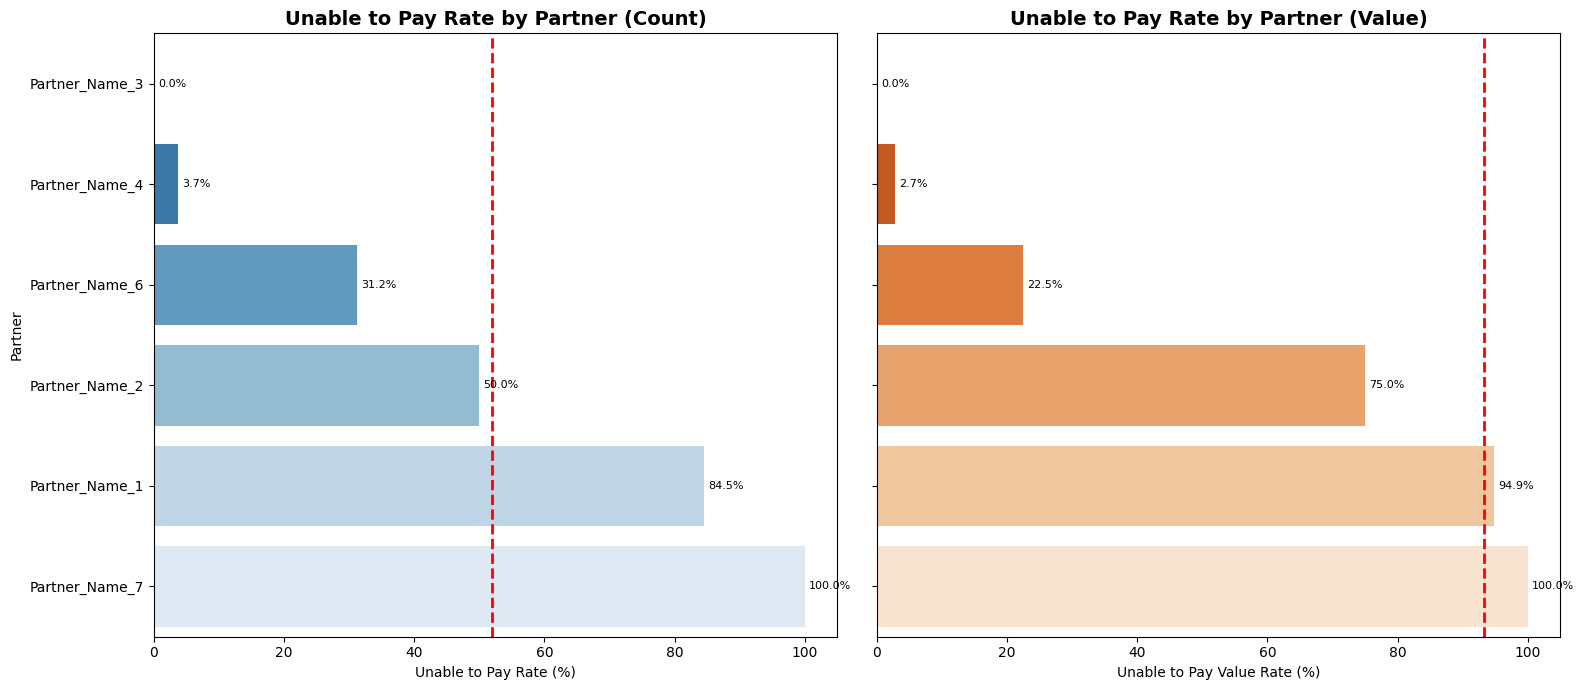

In [59]:
# ANALYSIS: Partner-level unable_to_pay risk (count + value)
print("\n" + "="*70)
print("PARTNER RISK ANALYSIS: UNABLE TO PAY RATE BY PARTNER")
print("="*70)

partner_risk = (
    df.assign(
        PARTNER_NAME=df['PARTNER_NAME'].fillna('Unknown'),
        is_unable_to_pay=df['DONATION_STATUS'].eq('unable_to_pay'),
        unable_value_usd=df['DONATION_AMOUNT_USD'].where(
            df['DONATION_STATUS'].eq('unable_to_pay'),
            0
        )
    )
    .groupby('PARTNER_NAME', dropna=False)
    .agg(
        total_donations=('DONATION_ID', 'count'),
        total_value_usd=('DONATION_AMOUNT_USD', 'sum'),
        unable_donations=('is_unable_to_pay', 'sum'),
        unable_value_usd=('unable_value_usd', 'sum')
    )
    .reset_index()
)

overall_unable_count_rate = df['DONATION_STATUS'].eq('unable_to_pay').mean()
overall_unable_value_rate = (
    df.loc[df['DONATION_STATUS'].eq('unable_to_pay'), 'DONATION_AMOUNT_USD'].sum()
    / df['DONATION_AMOUNT_USD'].sum()
)

partner_risk['unable_count_rate_pct'] = (
    partner_risk['unable_donations'] / partner_risk['total_donations'] * 100
).round(2)

partner_risk['unable_value_rate_pct'] = (
    partner_risk['unable_value_usd'] / partner_risk['total_value_usd'] * 100
).round(2)

partner_risk['count_risk_index'] = (
    partner_risk['unable_donations'] / partner_risk['total_donations']
    / overall_unable_count_rate
).round(2)

partner_risk['value_risk_index'] = (
    (partner_risk['unable_value_usd'] / partner_risk['total_value_usd'])
    / overall_unable_value_rate
).round(2)

partner_risk = partner_risk.sort_values(
    ['unable_value_rate_pct', 'unable_count_rate_pct'],
    ascending=False
)

print(f"\nOverall unable_to_pay count rate: {overall_unable_count_rate * 100:.2f}%")
print(f"Overall unable_to_pay value rate: {overall_unable_value_rate * 100:.2f}%")

print("\n--- Partner Risk Table ---")
print(
    partner_risk[
        [
            'PARTNER_NAME',
            'total_donations',
            'total_value_usd',
            'unable_donations',
            'unable_value_usd',
            'unable_count_rate_pct',
            'unable_value_rate_pct',
            'count_risk_index',
            'value_risk_index'
        ]
    ].to_string(index=False)
)

partner1_risk = partner_risk[partner_risk['PARTNER_NAME'] == 'Partner_Name_1']
if not partner1_risk.empty:
    row = partner1_risk.iloc[0]
    print("\n--- Partner_Name_1 Risk Summary ---")
    print(f"Unable-to-pay count rate: {row['unable_count_rate_pct']:.2f}%")
    print(f"Unable-to-pay value rate: {row['unable_value_rate_pct']:.2f}%")
    print(f"Count risk index vs portfolio: {row['count_risk_index']:.2f}x")
    print(f"Value risk index vs portfolio: {row['value_risk_index']:.2f}x")

# VISUALIZATION: Partner unable_to_pay risk vs portfolio
plot_risk = partner_risk.sort_values('unable_value_rate_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

sns.barplot(
    data=plot_risk,
    y='PARTNER_NAME',
    x='unable_count_rate_pct',
    hue='PARTNER_NAME',
    palette='Blues_r',
    ax=axes[0],
    legend=False
)
annotate_bar_values(axes[0], fmt='{:.1f}%', padding=3, fontsize=8)
axes[0].axvline(overall_unable_count_rate * 100, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Unable to Pay Rate by Partner (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Unable to Pay Rate (%)')
axes[0].set_ylabel('Partner')

sns.barplot(
    data=plot_risk,
    y='PARTNER_NAME',
    x='unable_value_rate_pct',
    hue='PARTNER_NAME',
    palette='Oranges_r',
    ax=axes[1],
    legend=False
)
annotate_bar_values(axes[1], fmt='{:.1f}%', padding=3, fontsize=8)
axes[1].axvline(overall_unable_value_rate * 100, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Unable to Pay Rate by Partner (Value)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Unable to Pay Value Rate (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('11_partner_unable_to_pay_risk.png', dpi=300)
print("Saved: 11_partner_unable_to_pay_risk.png")

Saved: 12_partner_monthly_volume_value.png


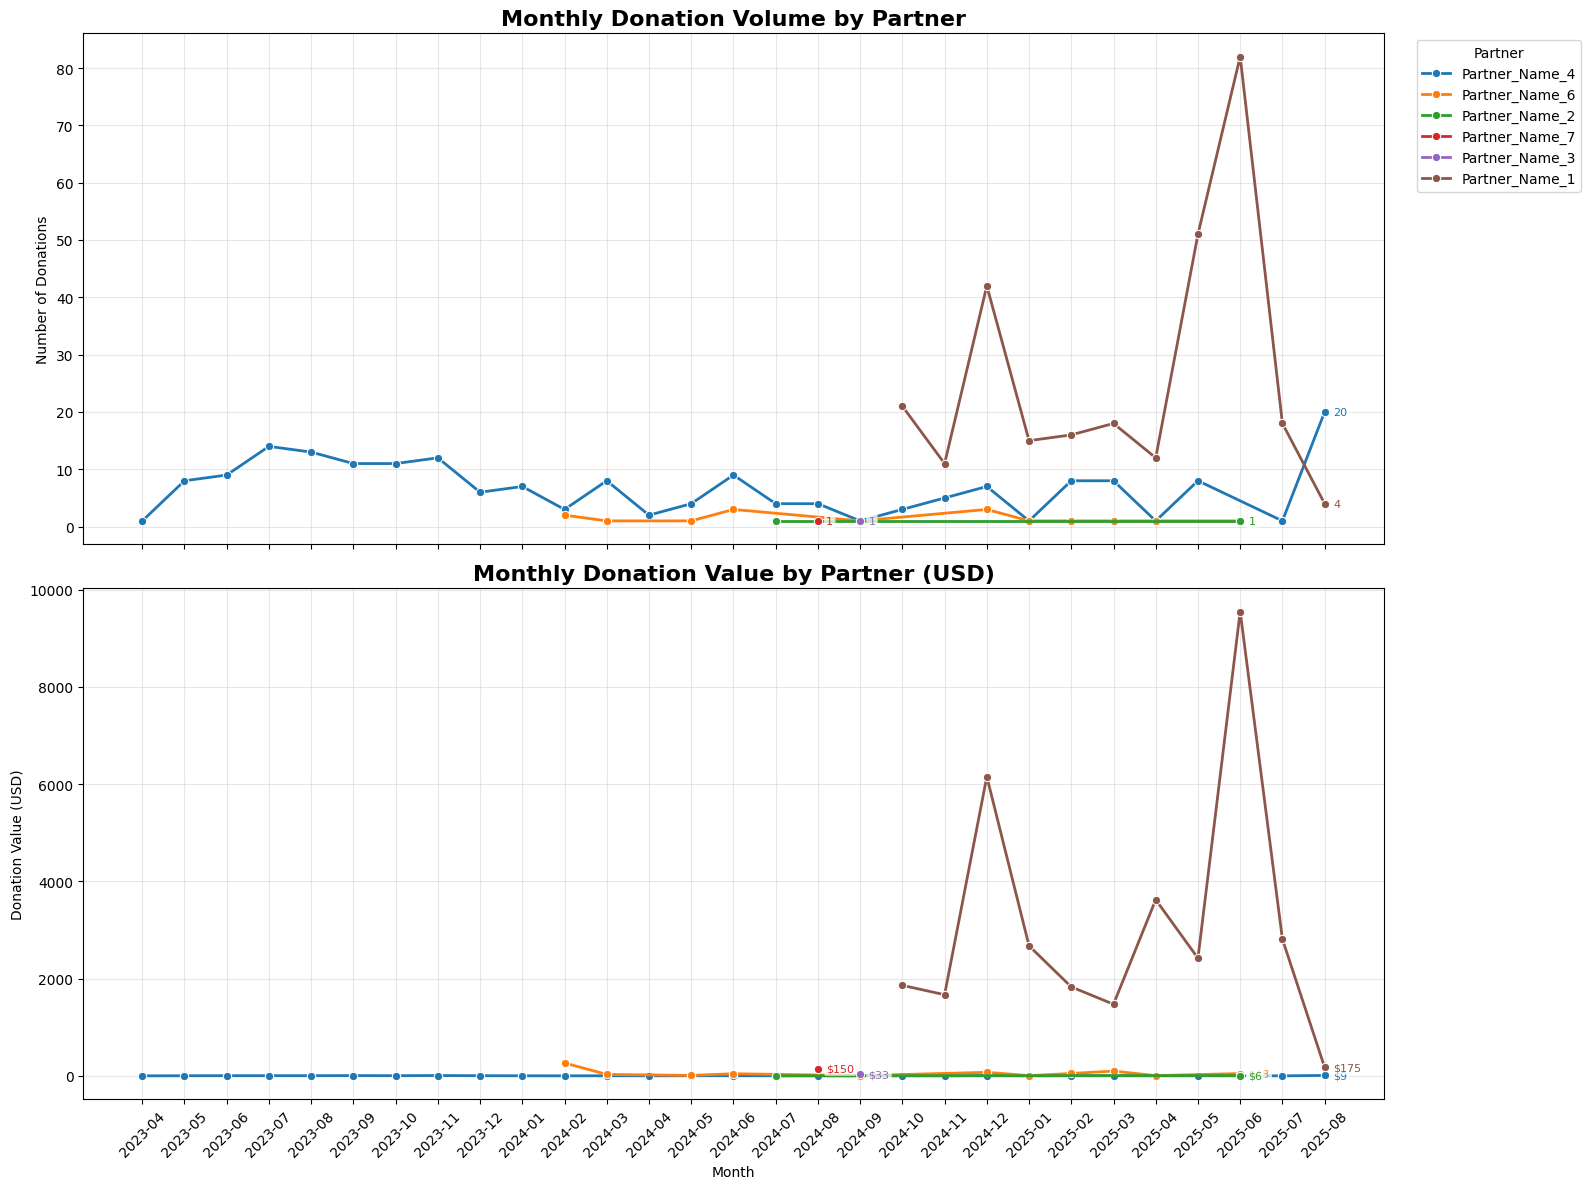

In [60]:
# VISUALIZATION: Monthly donation volume and value by partner
partner_monthly = (
    df.assign(PARTNER_NAME=df['PARTNER_NAME'].fillna('Unknown'))
    .groupby(['MONTH_YEAR', 'PARTNER_NAME'], dropna=False)
    .agg(
        donation_count=('DONATION_ID', 'count'),
        donation_value_usd=('DONATION_AMOUNT_USD', 'sum')
    )
    .reset_index()
    .sort_values('MONTH_YEAR')
)

partner_monthly['MONTH_YEAR'] = partner_monthly['MONTH_YEAR'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

sns.lineplot(
    data=partner_monthly,
    x='MONTH_YEAR',
    y='donation_count',
    hue='PARTNER_NAME',
    marker='o',
    linewidth=2,
    ax=axes[0]
)
annotate_line_endpoints(axes[0], fmt='{:.0f}', fontsize=8)
axes[0].set_title('Monthly Donation Volume by Partner', fontsize=16, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Donations')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Partner', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

sns.lineplot(
    data=partner_monthly,
    x='MONTH_YEAR',
    y='donation_value_usd',
    hue='PARTNER_NAME',
    marker='o',
    linewidth=2,
    ax=axes[1],
    legend=False
)
annotate_line_endpoints(axes[1], fmt='${:,.0f}', fontsize=8)
axes[1].set_title('Monthly Donation Value by Partner (USD)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Donation Value (USD)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('12_partner_monthly_volume_value.png', dpi=300)
print("Saved: 12_partner_monthly_volume_value.png")

Saved: 13_partner_monthly_volume_excluding_unable_to_pay.png


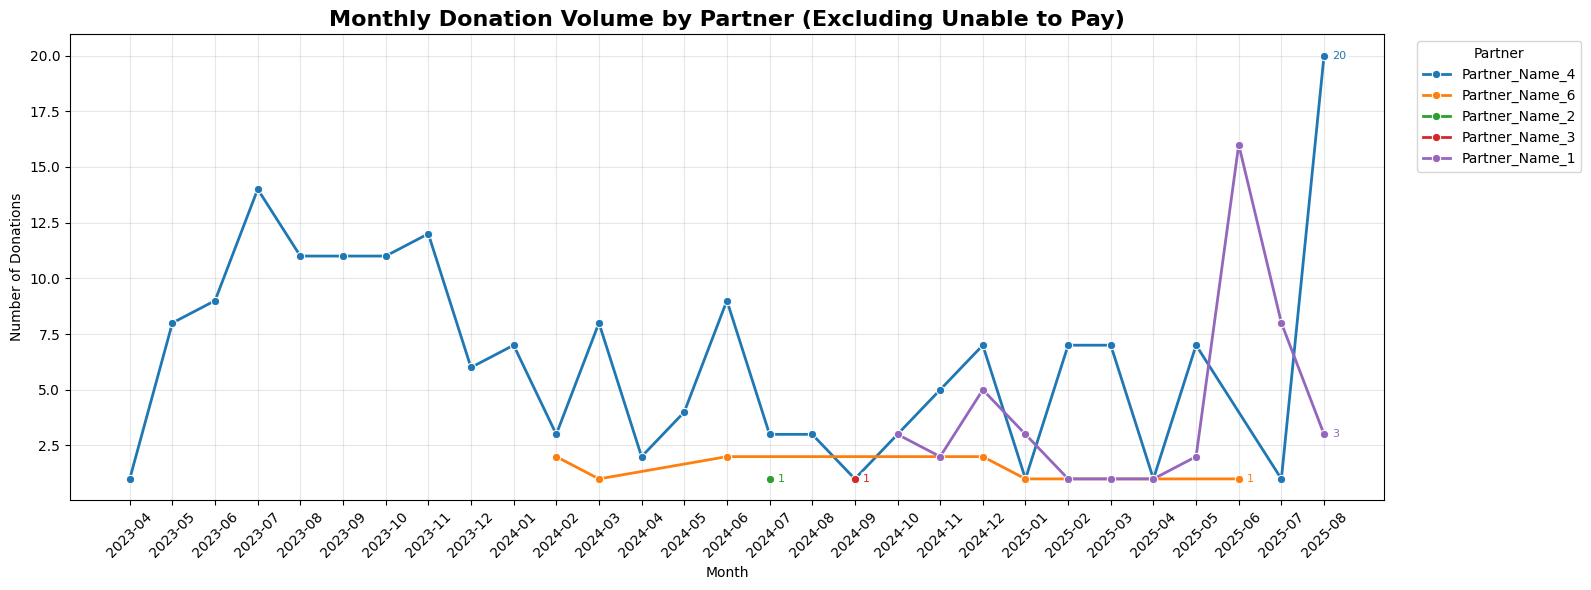

In [61]:
# VISUALIZATION: Monthly donation volume by partner (excluding unable_to_pay)
partner_monthly_non_unable = (
    df.loc[df['DONATION_STATUS'] != 'unable_to_pay']
    .assign(PARTNER_NAME=lambda frame: frame['PARTNER_NAME'].fillna('Unknown'))
    .groupby(['MONTH_YEAR', 'PARTNER_NAME'], dropna=False)
    .agg(donation_count=('DONATION_ID', 'count'))
    .reset_index()
    .sort_values('MONTH_YEAR')
)

partner_monthly_non_unable['MONTH_YEAR'] = partner_monthly_non_unable['MONTH_YEAR'].astype(str)

plt.figure(figsize=(16, 6))
ax = sns.lineplot(
    data=partner_monthly_non_unable,
    x='MONTH_YEAR',
    y='donation_count',
    hue='PARTNER_NAME',
    marker='o',
    linewidth=2
)
annotate_line_endpoints(ax, fmt='{:.0f}', fontsize=8)

plt.title('Monthly Donation Volume by Partner (Excluding Unable to Pay)', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Donations')
plt.xticks(rotation=45)
plt.legend(title='Partner', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('13_partner_monthly_volume_excluding_unable_to_pay.png', dpi=300)
print("Saved: 13_partner_monthly_volume_excluding_unable_to_pay.png")

In [38]:

# TABLE: Top Partners
print("\n=== TOP PARTNERS BY DONATION VALUE ===")
top_partners_table = top_partners.reset_index()
top_partners_table.columns = ['Partner Name', 'Total USD']
top_partners_table['% of Total'] = (top_partners_table['Total USD'] / total_usd * 100).round(2)
top_partners_table['Donation Count'] = [df[df['PARTNER_NAME'] == partner].shape[0] for partner in top_partners_table['Partner Name']]
print(top_partners_table.to_string(index=False))



=== TOP PARTNERS BY DONATION VALUE ===
  Partner Name    Total USD  % of Total  Donation Count
Partner_Name_1 34244.018628       97.47             290
Partner_Name_6   630.480000        1.79              16
Partner_Name_7   150.000000        0.43               1
Partner_Name_4    68.580990        0.20             189
Partner_Name_3    32.685581        0.09               1
Partner_Name_2     8.000000        0.02               2


In [40]:
# TABLE: Top 10 Countries
print("\n=== TOP 10 COUNTRIES BY DONATION VALUE ===")
top_10_countries_table = (
    df.groupby('ORGANISATION_COUNTRY', as_index=False)['DONATION_AMOUNT_USD']
    .sum()
    .sort_values('DONATION_AMOUNT_USD', ascending=False)
    .head(10)
    .rename(columns={
        'ORGANISATION_COUNTRY': 'Country',
        'DONATION_AMOUNT_USD': 'Total USD'
    })
)
top_10_countries_table['% of Total'] = (top_10_countries_table['Total USD'] / total_usd * 100).round(2)
print(top_10_countries_table.to_string(index=False))


=== TOP 10 COUNTRIES BY DONATION VALUE ===
       Country    Total USD  % of Total
United Kingdom 10918.213293       31.08
     Australia  9849.514864       28.03
       Germany  4785.978460       13.62
       Romania  3046.421783        8.67
   Netherlands  2155.668166        6.14
 United States  1474.064225        4.20
         India   633.764601        1.80
         Italy   601.562620        1.71
       Ukraine   346.293283        0.99
        Brazil   268.993726        0.77


In [41]:

# TABLE: Monthly Trends - Cumulative Donations Over Time
print("\n=== CUMULATIVE DONATIONS OVER TIME ===")
print(monthly_trends.to_string(index=False))
cumulative_usd = monthly_trends['DONATION_AMOUNT_USD'].cumsum()
print(f"\nFinal Cumulative Total: ${cumulative_usd.iloc[-1]:,.2f}")



=== CUMULATIVE DONATIONS OVER TIME ===
MONTH_YEAR  DONATION_AMOUNT_USD
   2023-04             0.260108
   2023-05             2.308462
   2023-06             3.413923
   2023-07             3.530972
   2023-08             2.588079
   2023-09             5.104628
   2023-10             3.348896
   2023-11             6.879868
   2023-12             2.919717
   2024-01             1.716716
   2024-02           265.419179
   2024-03            31.392869
   2024-04             0.915356
   2024-05             2.773538
   2024-06            42.261218
   2024-07             2.281723
   2024-08             1.198062
   2024-09            33.027267
   2024-10            45.490340
   2024-11           164.278077
   2024-12           220.977274
   2025-01           137.116455
   2025-02            54.406713
   2025-03             5.533730
   2025-04             8.147569
   2025-05            81.405304
   2025-06           427.440523
   2025-07           642.329169
   2025-08           149.289625
